### Full workflow for XRD-conditioned crystal structure recovery (CHILI-100K Study)

In [ ]:
import __init__
import pandas as pd
from _utils._notebook_utils.x_xrd_chili100k_utils import get_stratified_metrics_xrd

### Two-Pass Finetuning Setup

The model is finetuned in two sequential passes before evaluation:

- **Pass 1** - finetune on a broad XRD-labelled dataset (Mattergen/Alex-MP-20) to teach the model the XRD condition format and get initial exposure to diverse crystal chemistries
- **Pass 2** - continue finetuning on CHILI-100K with the same XRD conditioning, using the leakproof stratified split built below

The text-only baseline mirrors this exact pipeline but with XRD info stripped out at every stage, so any metric difference is attributable to the XRD signal alone.

#### 1st pass finetune - Mattergen XRD
- Dataset Source: [Mattergen Alex-MP-20](https://github.com/microsoft/mattergen/tree/main/data-release/alex-mp)
  - Columns: Database (manual) 
  - Reduced Formula (Source)
  - CIF (pmg - CifWriter with symprec 0.1)
  - XRD 'Condition Vector' (with [_calculate_theor_XRD.py](_utils/_preprocessing/_calculate_theor_XRD.py))
    - pmg - XRDCalculator(wavelength="CuKa")
    - top 20 most intense peaks selected ($2\theta$ and int)
    - Normalisations
      - $2\theta$ min-max for 0,90
      - intensities min-max for 0,100
- Deduplicated
- Cleaned for CIF augmentation
  -  Note: I didnt filter to context length here because it was not implemented yet, but filter to context was flagged as True during model training which effectively does the same thing (less efficient)
- dataset pushed to HuggingFace as: c-bone/mattergen_XRD (90:10 train/valid sets)

In [ ]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/conditional/xrd_studies/mattergen_XRD-slider.jsonc'

#### 2nd pass finetune - CHILI-100K XRD
- Dataset Source: [CHILI-100K](https://github.com/UlrikFriisJensen/CHILI)
  - Columns: `Database`, `Material ID`, `Reduced Formula`, `CIF`
  - CIF source: generated structures by extracting structures from the dataset and then CifWriter with symprec 0.1
- Preprocessing and filtering
  - deduplicated the raw parquet
  - Added theoretical XRD peaks with [_calculate_theor_XRD.py](_utils/_preprocessing/_calculate_theor_XRD.py)
    - pmg - `XRDCalculator(wavelength="CuKa")`
    - top 20 most intense peaks selected ($2\theta$ and int)
    - Normalisations
      - $2\theta$ min-max for 0,90
      - intensities min-max for 0,100
  - Ran VUN metrics against `c-bone/lematerial_clean` and filtered to the 1536-token context limit
  - Built a leakproof split with mutually exclusive novelty tiers
    - test: 500 seen + 500 structurally novel + 500 compositionally novel
    - val: 1500 in-distribution structures
    - train: remaining rows
- Final dataset cleaned for CIF augmentation and pushed to HuggingFace as: `c-bone/chili100k_strat`

#### Making the dataset

Full preprocessing pipeline: load raw -> deduplicate -> add theoretical XRD peaks -> tag novelty -> filter to context length -> build leakproof split -> clean -> push to HF.

**Step 1: have a look at the raw parquet**

In [ ]:
df = pd.read_parquet('/home/cyprien/Data_Gen/chili100k_data.parquet')
df.head()

**Step 2: Deduplicate** removes identical CIFs so they can't appear in both train and test

In [ ]:
!python _utils/_preprocessing/_deduplicate.py \
  --input_parquet /home/cyprien/Data_Gen/chili100k_data.parquet \
  --output_parquet HF-databases/chili100k/chili100k_dedup.parquet

**Step 3: Add theoretical XRD condition vectors** simulates Cu Kα XRD, selects the 20 most intense peaks, and normalises $2\theta$ and intensities to fixed ranges. This is the condition signal fed to the model.

In [ ]:
!python _utils/_preprocessing/_calculate_theor_XRD.py \
    --input_parquet HF-databases/chili100k/chili100k_dedup.parquet \
    --output_parquet HF-databases/chili100k/chili100k_dedup.parquet \
    --num_workers 16

**Step 4: Tag novelty against the training database** each structure is labelled as *seen* (matches something in LeMaterial), *structurally novel* (same composition, different structure), or *compositionally novel* (entirely new composition). This is what lets us build the leakproof split and report stratified results later.

In [ ]:
!python _utils/_metrics/VUN_metrics.py \
    --input_parquet HF-databases/chili100k/chili100k_dedup.parquet \
    --huggingface_dataset "c-bone/lematerial_clean" \
    --load_processed_data "HF-databases/lematerial/lematerial_dedup.parquet" \
    --output_parquet HF-databases/chili100k/chili100k_dedup_vun.parquet \
    --output_csv HF-databases/chili100k/chili100k_dedup_vun.csv \
    --check_comp_novelty \
    --num_workers 32 \
    --bond_length_acceptability_cutoff 0.0

> Note: We remove invalid CIFs here, but set bond_length_acceptability_cutoff to 0.0 to avoid filtering out the experimentally observed materials that would fail this check.
> Otherwise, the goal here is to make sure no CIF info is leaked from any training phase to test phase apart from the 500 seen subset

**Step 5: Filter to context length** count tokens per CIF and drop anything above 1536 (which will bethe model's context window). The two cells below do this: first count, then filter. For more stats on the dataset see [Y_Dataset_stats.ipynb](notebooks/Y_Dataset_stats.ipynb).

In [ ]:
!python _utils/_preprocessing/_cleaning.py \
    --input_parquet HF-databases/chili100k/chili100k_dedup_vun.parquet \
    --output_parquet HF-databases/chili100k/chili100k_count.parquet \
    --num_workers 32 \
    --count_tokens

In [ ]:
df_count = pd.read_parquet('HF-databases/chili100k/chili100k_count.parquet')
df_dedup = pd.read_parquet('HF-databases/chili100k/chili100k_dedup_vun.parquet')

df_merged = pd.merge(df_dedup, df_count[['Material ID', 'token_count']], on='Material ID', how='inner')
df_filtered = df_merged[df_merged['token_count'] <= 1536]
df_filtered.to_parquet('HF-databases/chili100k/chili100k_dedup_vun_filtered.parquet', index=False)

**Step 6: Build the leakproof stratified split** from the tiered dataset, 500 samples are drawn from each novelty tier (seen, structurally novel, compositionally novel) for the test set. Val gets 1500 in-distribution structures. Everything else is train.

In [ ]:
df = pd.read_parquet('HF-databases/chili100k/chili100k_dedup_vun_filtered.parquet')

df = df[~((df['is_valid'] == False) & (df['is_unique'] == False))]
df = df.drop(columns=['is_valid', 'is_unique'])

# Define strictly mutually exclusive masks to prevent data overlap
# mask_comp_novel = df['is_comp_novel'] == True and 'Reduced Formula' is unique in the dataset
# We want to ensure that if a composition is marked as novel, it does not have duplicates in the dataset, which could leak information across splits. Therefore, we check for both conditions: is_comp_novel is True and the Reduced Formula is not duplicated (i.e., unique).
mask_comp_novel = (df['is_comp_novel'] == True) & (df['Reduced Formula'].duplicated(keep=False) == False)
print(f"Number of comp novel structures: {mask_comp_novel.sum()}")
mask_struct_novel = (df['is_novel'] == True) & (df['is_comp_novel'] == False)
mask_in_dist = df['is_novel'] == False 

# Sample the test set
test_comp = df[mask_comp_novel].sample(n=500, random_state=1)
test_struct = df[mask_struct_novel].sample(n=500, random_state=1)
test_in_dist = df[mask_in_dist].sample(n=500, random_state=1)
test_indices = pd.concat([test_comp, test_struct, test_in_dist]).index

# Filter out the test set to define the remaining pool
remaining_df = df.drop(test_indices)

# Sample the validation set (1500 from in-distribution structures)
val_indices = remaining_df[remaining_df['is_novel'] == False].sample(n=1500, random_state=1).index

df['Split'] = 'train'
df.loc[val_indices, 'Split'] = 'val'
df.loc[test_indices, 'Split'] = 'test'

print(df['Split'].value_counts())

# renam 'Generated CIF' to CIF
df = df.rename(columns={'Generated CIF': 'CIF'})
df.to_parquet('HF-databases/chili100k/chili100k_dedup_leakproof.parquet', index=False)

**Steps 7 & 8: Clean for CIF augmentation and push to HuggingFace** final formatting pass then upload as `c-bone/chili100k_strat`

In [ ]:
!python _utils/_preprocessing/_cleaning.py \
    --input_parquet 'HF-databases/chili100k/chili100k_dedup_leakproof.parquet' \
    --output_parquet 'HF-databases/chili100k/chili100k_clean.parquet' \
    --num_workers 32 \
    --count_tokens

In [ ]:
!python _utils/_preprocessing/_save_dataset_to_HF.py \
    --input_parquet 'HF-databases/chili100k/chili100k_clean.parquet' \
    --output_parquet 'HF-databases/chili100k_strat.parquet' \
    --save_hub

### Training

In [ ]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/conditional/xrd_studies/chili100k-xrd-slider-opt.jsonc'

> This model's weights are loaded from the 1st pass (Mattergen XRD) described at the top of the notebook

### Generating

First create prompts from the held-out CHILI-100K test split, then run repeated generations for the conditioned and text-only baselines.

Each prompt packages the formula header + XRD condition vector for one test structure — the model then completes the CIF. `level_3` uses the full composition + XRD signal; `condition_vector` is the encoded XRD peaks.

In [ ]:
!python _utils/_generating/make_prompts.py \
    --HF_dataset 'c-bone/chili100k_strat' \
    --split 'test' \
    --automatic \
    --output_parquet '_artifacts/chili-xrd/chili-test_prompts.parquet' \
    --level 'level_3' \
    --condition_columns 'condition_vector'

#### Generate materials from the Chili model and XRD information (Repeated 3x)

In [ ]:
!python _utils/_generating/generate_CIFs.py --config '_config_files/generation/conditional/xrd_studies/chili-xrd_eval.jsonc'

In [ ]:
!python _utils/_generating/postprocess.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-20perp-test_gen.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-20perp-test_post.parquet' \
    --num_workers 32 \
    --column_name 'Generated CIF'

In [ ]:
!python _utils/_metrics/XRD_metrics.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-20perp-test_gen.parquet' \
    --num_gens 20 \
    --ref_parquet 'HF-databases/chili100k/chili100k_dedup_leakproof.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-20perp-test_metrics.parquet' \
    --num_workers 32 \
    --validity_check "none"

`num_gens=20` uses all 20 generated structures per prompt (best-of-20 scoring). `num_gens=1` uses only the first perplexity ranked structure. Both are useful: 20-perp shows the ceiling of what the model can do, 1-perp shows what you'd get in a closed loop best guess

In [ ]:
!python _utils/_metrics/XRD_metrics.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-20perp-test_gen.parquet' \
    --num_gens 1 \
    --ref_parquet 'HF-databases/chili100k/chili100k_dedup_leakproof.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-1perp-test_metrics.parquet' \
    --num_workers 32 \
    --validity_check "none"

#### Comparison to text-only model

We mirror the exact same training pipeline as above, however here we never let the model see XRD info in any of the training phase to understand the gains from XRD conditioning across the board

> **Note**: This comparison keeps the same held-out CHILI-100K prompt split, but switches to the unconditional 2-pass finetuning so the effect of the XRD channel can be isolated.

**Pass 1: text-only Mattergen finetune** (same data as conditioned pass 1 but XRD stripped)

In [ ]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/conditional/xrd_studies/mattergen_XRD-uncond.jsonc'

**Pass 2: text-only CHILI-100K finetune**

In [ ]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/conditional/xrd_studies/chili100k-uncond-opt.jsonc'

Generate, postprocess, and score same sequence as the conditioned model above

In [ ]:
!python _utils/_generating/generate_CIFs.py --config '_config_files/generation/conditional/xrd_studies/chili-xrd-uncond_eval.jsonc'

In [ ]:
!python _utils/_generating/postprocess.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_gen.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_post.parquet' \
    --num_workers 32 \
    --column_name 'Generated CIF'

In [ ]:
!python _utils/_metrics/XRD_metrics.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_gen.parquet' \
    --num_gens 20 \
    --ref_parquet 'HF-databases/chili100k/chili100k_dedup_leakproof.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics.parquet' \
    --num_workers 32 \
    --validity_check "none"

In [ ]:
!python _utils/_metrics/XRD_metrics.py \
    --input_parquet '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_gen.parquet' \
    --num_gens 1 \
    --ref_parquet 'HF-databases/chili100k/chili100k_dedup_leakproof.parquet' \
    --output_parquet '_artifacts/chili-xrd/chili-ft-uncond-1perp-test_metrics.parquet' \
    --num_workers 32 \
    --validity_check "none"

Same scoring as above: `num_gens=20` for best-of-20, `num_gens=1` for single-shot.

### Aggregate Results

Aggregate the repeated conditioned and text-only runs, then report stratified averages with standard errors across the three repeats.

Each model variant was run 3 times (v1/v2/v3) to get a sense of variance. Keys follow the pattern `<cond|uncond>-<Nperp>`: `cond` = XRD-conditioned, `uncond` = text-only baseline, `Nperp` = number of generations used for scoring (20 = best-of-20, 1 = best ranked).

**Tiers:** *Memorized* = test structures the model has seen composition+structure of before; *Structurally Novel* = seen composition, new structure; *Compositionally Novel* = completely new composition. This lets us see where the XRD signal helps most.

In [6]:
import __init__
import pandas as pd
import numpy as np
from _utils._notebook_utils.x_xrd_chili100k_utils import get_stratified_metrics_xrd

In [4]:
paths = {
    'cond-20perp': '_artifacts/chili-xrd/chili-ft-20perp-test_metrics1.parquet',
    'cond-20perp-v2': '_artifacts/chili-xrd/chili-ft-20perp-test_metrics2.parquet',
    'cond-20perp-v3': '_artifacts/chili-xrd/chili-ft-20perp-test_metrics3.parquet',
    'cond-1perp': '_artifacts/chili-xrd/chili-ft-1perp-test_metrics1.parquet',
    'cond-1perp-v2': '_artifacts/chili-xrd/chili-ft-1perp-test_metrics2.parquet',
    'cond-1perp-v3': '_artifacts/chili-xrd/chili-ft-1perp-test_metrics3.parquet',
    'uncond-20perp': '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics1.parquet',
    'uncond-20perp-v2': '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics2.parquet',
    'uncond-20perp-v3': '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics3.parquet',
    'uncond-1perp': '_artifacts/chili-xrd/chili-ft-uncond-1perp-test_metrics1.parquet',
    'uncond-1perp-v2': '_artifacts/chili-xrd/chili-ft-uncond-1perp-test_metrics2.parquet',
    'uncond-1perp-v3': '_artifacts/chili-xrd/chili-ft-uncond-1perp-test_metrics3.parquet',
}

tier_sizes = {
    'Overall': 1500,
    'Memorized (Seen Comp & Struct)': 500,
    'Structurally Novel (Seen Comp)': 500,
    'Compositionally Novel (Unseen Comp)': 500,
}

tables = {}
for run_name, parquet_path in paths.items():
    df_metrics = pd.read_parquet(parquet_path)
    tables[run_name] = get_stratified_metrics_xrd(
        df_metrics,
        n_test=tier_sizes,
        only_matched=False,
        verbose=False,
    )

final_table = pd.concat(tables, names=['run', 'tier'])
final_table.index = [f'{run}__{tier}' for run, tier in final_table.index]
final_table.to_parquet('_artifacts/chili-xrd/chili-slider-vs-uncond-all-results.parquet')
final_table

,Total Structures,Matched,Match Rate (%),Mean RMS-d,a MAE,b MAE,c MAE,Vol MAE,a R^2,b R^2,c R^2,Vol R^2,Avg Score,Atom Count (matched mean),Atom Count (matched max),Atom Count (matched SE),Atom Count (unmatched mean),Atom Count (unmatched SE),Delta Atom Count (match - unmatch)
cond-20perp__Overall,1500.0,727.0,48.466667,0.115789,0.715731,0.715860,0.960071,43.713916,0.789117,0.793194,0.781115,0.929650,1.246767,18.870702,68.0,0.459779,36.295276,0.644533,-17.424574
cond-20perp__Memorized (Seen Comp & Struct),500.0,217.0,43.400000,0.114253,0.742058,0.643813,1.086495,40.135497,0.778336,0.868357,0.655378,0.948953,1.263171,21.341014,66.0,0.970032,39.168459,1.074883,-17.827445
cond-20perp__Structurally Novel (Seen Comp),500.0,301.0,60.200000,0.124446,0.715564,0.701295,0.843790,41.246544,0.792508,0.775327,0.900278,0.920522,1.208454,15.581395,68.0,0.602866,30.126904,1.196937,-14.545508
cond-20perp__Compositionally Novel (Unseen Comp),500.0,209.0,41.800000,0.104916,0.689519,0.802705,0.950375,49.781890,0.795008,0.722713,0.772730,0.905650,1.268874,21.043062,64.0,0.817950,37.741259,1.024595,-16.698197
cond-20perp-v2__Overall,1500.0,734.0,48.933333,0.113241,0.705483,0.723711,0.939104,44.972782,0.779513,0.790863,0.793519,0.927244,1.245657,19.227520,102.0,0.484718,36.054305,0.638659,-16.826784
cond-20perp-v2__Memorized (Seen Comp & Struct),500.0,235.0,47.000000,0.123950,0.765058,0.688499,1.048236,41.855507,0.754193,0.848896,0.688632,0.948362,1.272754,22.106383,102.0,1.008334,39.648855,1.071647,-17.542472
cond-20perp-v2__Structurally Novel (Seen Comp),500.0,299.0,59.800000,0.117435,0.727923,0.739341,0.848613,41.194110,0.757424,0.738201,0.905102,0.926812,1.201531,15.705686,68.0,0.607744,29.793970,1.199637,-14.088284
cond-20perp-v2__Compositionally Novel (Unseen Comp),500.0,200.0,40.000000,0.094390,0.622925,0.743379,0.920534,51.918258,0.825521,0.757628,0.775106,0.891739,1.262879,21.110000,66.0,0.885727,37.088435,0.996043,-15.978435
cond-20perp-v3__Overall,1500.0,746.0,49.733333,0.116725,0.725586,0.744288,0.927258,45.899800,0.773488,0.770205,0.805944,0.922656,1.247991,19.298928,80.0,0.477314,36.310902,0.647417,-17.011974
cond-20perp-v3__Memorized (Seen Comp & Struct),500.0,230.0,46.000000,0.118886,0.713071,0.690520,1.026914,42.089824,0.795718,0.852665,0.690566,0.941414,1.266950,22.273913,80.0,1.024864,39.233083,1.076672,-16.959170


In [8]:

final_table = pd.read_parquet('_artifacts/chili-xrd/chili-slider-vs-uncond-all-results.parquet')

base_conditions = {}
for index in final_table.index:
    if '-v2' in index:
        base_name = index.replace('-v2', '')
    elif '-v3' in index:
        base_name = index.replace('-v3', '')
    else:
        base_name = index
    
    if base_name not in base_conditions:
        base_conditions[base_name] = []
    base_conditions[base_name].append(index)

# averaged results with standard error between the 3 runs
averaged_results = {}
stderr_results = {}
for base_name, variants in base_conditions.items():
    variant_data = []
    for variant in variants:
        if variant in final_table.index:
            variant_data.append(final_table.loc[variant])
    
    if variant_data:
        data_df = pd.concat(variant_data, axis=1)
        averaged_results[base_name] = data_df.mean(axis=1)
        stderr_results[base_name] = data_df.std(axis=1) / np.sqrt(len(variant_data))

averaged_table = pd.DataFrame.from_dict(averaged_results, orient='index')
stderr_table = pd.DataFrame.from_dict(stderr_results, orient='index')

_ATOM_COUNT_COLS = {col for col in averaged_table.columns if 'Atom Count' in col}

formatted_table = pd.DataFrame(index=averaged_table.index, columns=averaged_table.columns, dtype=object)
for col in averaged_table.columns:
    fmt = ".0f" if col in _ATOM_COUNT_COLS else ".3f"
    for idx in averaged_table.index:
        mean_val = averaged_table.loc[idx, col]
        stderr_val = stderr_table.loc[idx, col]
        if pd.isna(stderr_val) or stderr_val == 0:
            formatted_table.loc[idx, col] = f"{mean_val:{fmt}}"
        else:
            formatted_table.loc[idx, col] = f"{mean_val:{fmt}} (±{stderr_val:{fmt}})"

formatted_table.to_csv('plots/chili/chili-slider-vs-uncond-all-results_formatted.csv')
formatted_table


,Total Structures,Matched,Match Rate (%),Mean RMS-d,a MAE,b MAE,c MAE,Vol MAE,a R^2,b R^2,c R^2,Vol R^2,Avg Score,Atom Count (matched mean),Atom Count (matched max),Atom Count (matched SE),Atom Count (unmatched mean),Atom Count (unmatched SE),Delta Atom Count (match - unmatch)
cond-20perp__Overall,1500.000,735.667 (±5.548),49.044 (±0.370),0.115 (±0.001),0.716 (±0.006),0.728 (±0.008),0.942 (±0.010),44.862 (±0.633),0.781 (±0.005),0.785 (±0.007),0.794 (±0.007),0.927 (±0.002),1.247 (±0.001),19 (±0),83 (±10),0 (±0),36 (±0),1 (±0),-17 (±0)
cond-20perp__Memorized (Seen Comp & Struct),500.000,227.333 (±5.364),45.467 (±1.073),0.119 (±0.003),0.740 (±0.015),0.674 (±0.015),1.054 (±0.017),41.360 (±0.616),0.776 (±0.012),0.857 (±0.006),0.678 (±0.011),0.946 (±0.002),1.268 (±0.003),22 (±0),83 (±10),1 (±0),39 (±0),1 (±0),-17 (±0)
cond-20perp__Structurally Novel (Seen Comp),500.000,301.333 (±1.453),60.267 (±0.291),0.120 (±0.002),0.729 (±0.008),0.719 (±0.011),0.842 (±0.005),42.109 (±0.889),0.770 (±0.011),0.750 (±0.013),0.901 (±0.002),0.921 (±0.003),1.205 (±0.002),16 (±0),68,1 (±0),30 (±0),1 (±0),-14 (±0)
cond-20perp__Compositionally Novel (Unseen Comp),500.000,207.000 (±3.606),41.400 (±0.721),0.103 (±0.005),0.678 (±0.029),0.790 (±0.024),0.931 (±0.010),51.147 (±0.685),0.794 (±0.018),0.728 (±0.016),0.789 (±0.015),0.898 (±0.004),1.268 (±0.003),21 (±0),65 (±1),1 (±0),38 (±0),1 (±0),-16 (±0)
cond-1perp__Overall,1500.000,515.333 (±2.404),34.356 (±0.160),0.104 (±0.000),1.505 (±0.031),1.653 (±0.007),2.194 (±0.020),53.265 (±0.432),0.338 (±0.011),0.288 (±0.015),0.372 (±0.022),0.895 (±0.006),1.217 (±0.001),17 (±0),68 (±2),1 (±0),33 (±0),1 (±0),-16 (±0)
cond-1perp__Memorized (Seen Comp & Struct),500.000,160.333 (±2.186),32.067 (±0.437),0.107 (±0.003),1.635 (±0.030),1.761 (±0.035),2.304 (±0.038),53.384 (±1.203),0.290 (±0.012),0.271 (±0.021),0.300 (±0.017),0.887 (±0.015),1.238 (±0.000),20 (±0),68 (±2),1 (±0),37 (±0),1 (±0),-17 (±0)
cond-1perp__Structurally Novel (Seen Comp),500.000,207.333 (±3.180),41.467 (±0.636),0.111 (±0.002),1.329 (±0.030),1.336 (±0.030),1.785 (±0.033),46.032 (±1.374),0.406 (±0.022),0.382 (±0.006),0.645 (±0.013),0.906 (±0.002),1.165 (±0.000),14 (±0),61 (±4),1 (±0),26 (±0),1 (±0),-12 (±0)
cond-1perp__Compositionally Novel (Unseen Comp),500.000,147.667 (±1.856),29.533 (±0.371),0.090 (±0.001),1.550 (±0.044),1.864 (±0.034),2.496 (±0.029),60.423 (±0.732),0.324 (±0.017),0.225 (±0.022),0.227 (±0.022),0.878 (±0.003),1.248 (±0.002),19 (±0),61 (±3),1 (±0),36 (±0),1 (±0),-17 (±0)
uncond-20perp__Overall,1500.000,238.333 (±2.028),15.889 (±0.135),0.135 (±0.001),1.078 (±0.014),1.172 (±0.004),1.466 (±0.013),101.669 (±0.172),0.648 (±0.012),0.628 (±0.003),0.613 (±0.009),0.662 (±0.007),1.312 (±0.000),11 (±0),40,1 (±0),29 (±0),0 (±0),-18 (±0)
uncond-20perp__Memorized (Seen Comp & Struct),500.000,71.000 (±1.732),14.200 (±0.346),0.135 (±0.005),1.049 (±0.016),1.201 (±0.014),1.439 (±0.016),107.124 (±2.387),0.708 (±0.012),0.615 (±0.005),0.563 (±0.008),0.675 (±0.013),1.329 (±0.005),11 (±0),40,1 (±0),33 (±0),1 (±0),-21 (±0)


> Note: the results here differ very slightly from any pooled plots because this table averages each repeated run first and then reports the associated stderr, rather than concatenating all rows across repeats before computing summary statistics.

### Plots

Scatter plots of true XRD peaks (from the reference structure) vs generated XRD peaks (from the best matched generated structure). Points on the diagonal mean perfect recovery. Matched structures (a best-of-20 match was found) are shown separately from unmatched ones. The conditioned model should cluster tighter around the diagonal than the text-only baseline.

Navigated to package root
Loaded 4,467 total rows.
Number of rows with None in True a: 0
Max value in 'System' column: 6
Mean RMS-d (excluding NaNs): 0.115

'conv_count' missing. Calculating atom counts with 32 workers...


Parsing fallback geometries: 100%|██████████| 4467/4467 [00:08<00:00, 512.31it/s] 


Successfully parsed 4467 structures.

Number of rows with None RMS-d values: 2260
Percentage of matches: 49.41%



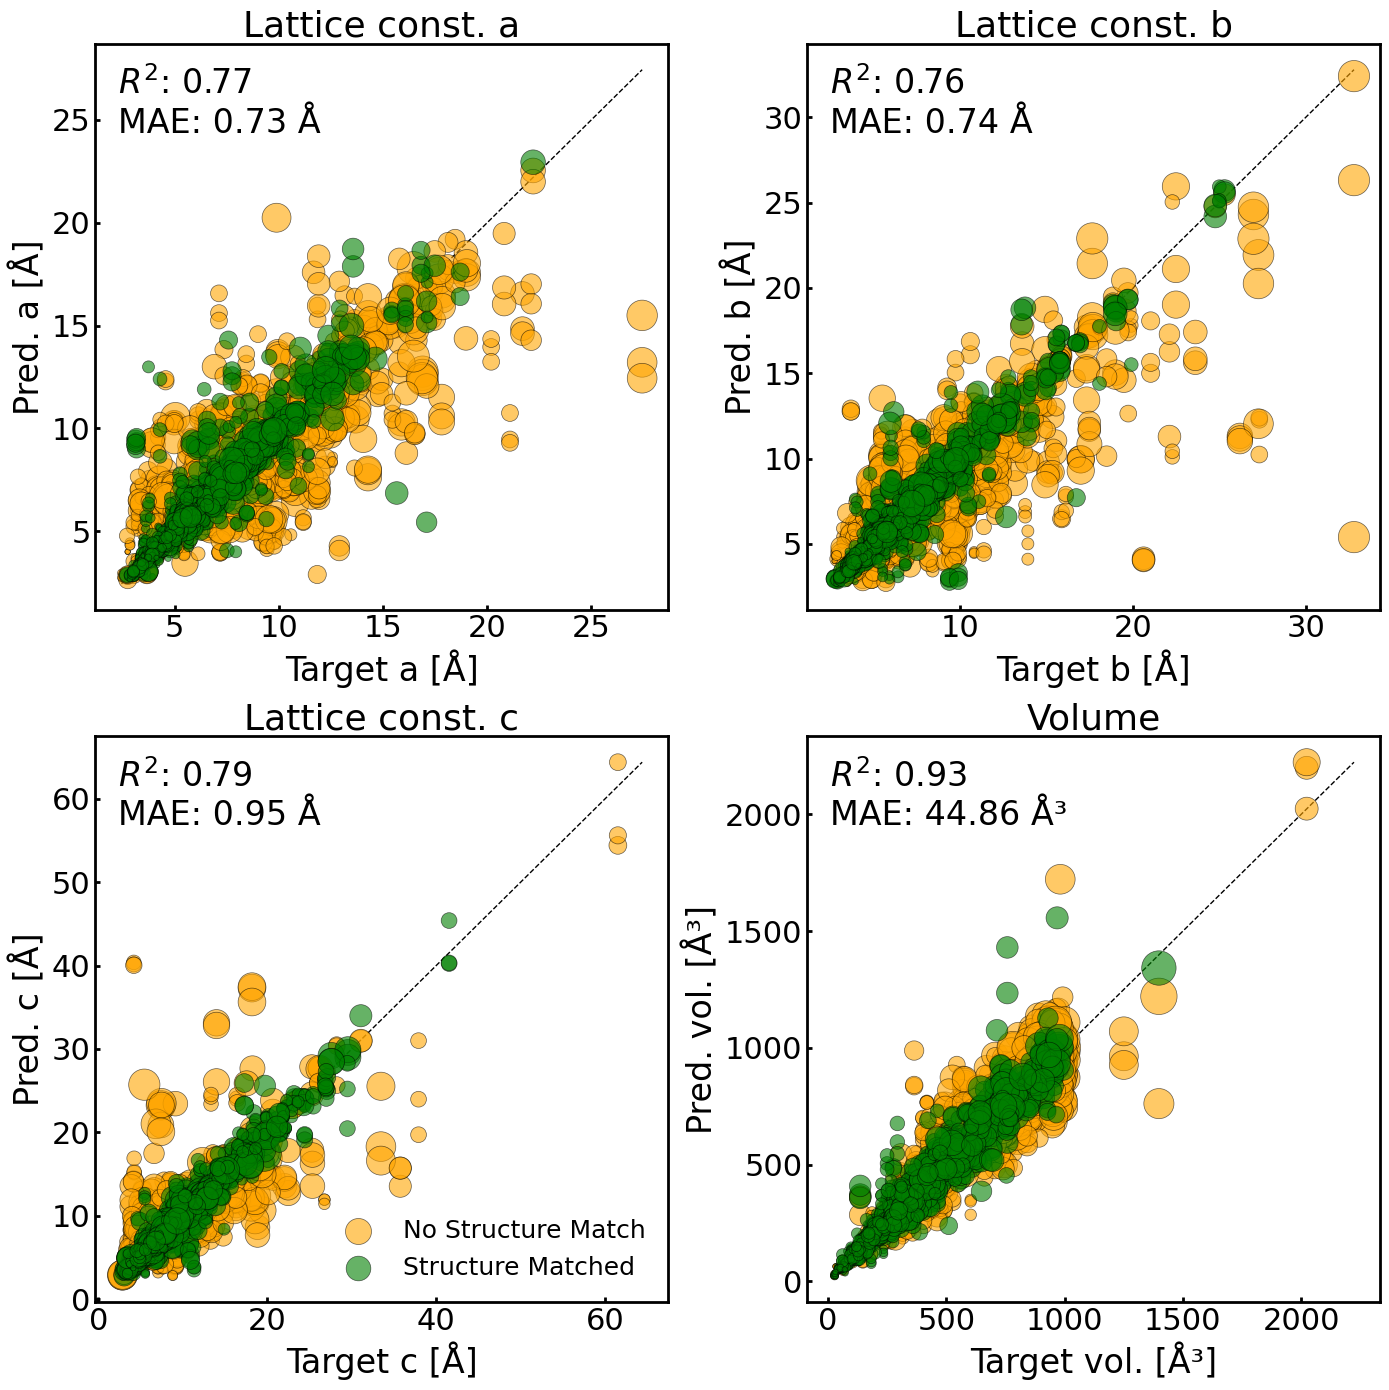

In [1]:
import __init__
from _utils._notebook_utils.x_xrd_chili100k_utils import load_and_process_xrd_metrics, plot_true_vs_gen

cond_files = [
    '_artifacts/chili-xrd/chili-ft-20perp-test_metrics1.parquet',
    '_artifacts/chili-xrd/chili-ft-20perp-test_metrics2.parquet',
    '_artifacts/chili-xrd/chili-ft-20perp-test_metrics3.parquet'
]

df_metrics = load_and_process_xrd_metrics(cond_files)

plot_true_vs_gen(
    df_metrics,
    figsize=(14, 14),
    title_fontsize=26,
    label_fontsize=24,
    ticks_fontsize=22,
    legend_fontsize=18,
    annot_fontsize=22,
    scatter_edge_width=0.5,
    alpha_matched=0.6,
    alpha_unmatched=0.6,
    min_marker_size=3,
    size_multiplier=6.0,
    diag_line_width=1.0,
    axes_linewidth=2.0,
    show_match_legend=True,
    show_size_legend=False,
    savepath="plots/chili/chili_xrd_cond.png"
)

Same plot for the text-only baseline — compare directly to the conditioned plot above to see the effect of the XRD signal.

Loaded 3,808 total rows.
Number of rows with None in True a: 0
Max value in 'System' column: 6
Mean RMS-d (excluding NaNs): 0.135

'conv_count' missing. Calculating atom counts with 32 workers...


Parsing fallback geometries: 100%|██████████| 3808/3808 [00:05<00:00, 653.58it/s]


Successfully parsed 3808 structures.

Number of rows with None RMS-d values: 3093
Percentage of matches: 18.78%



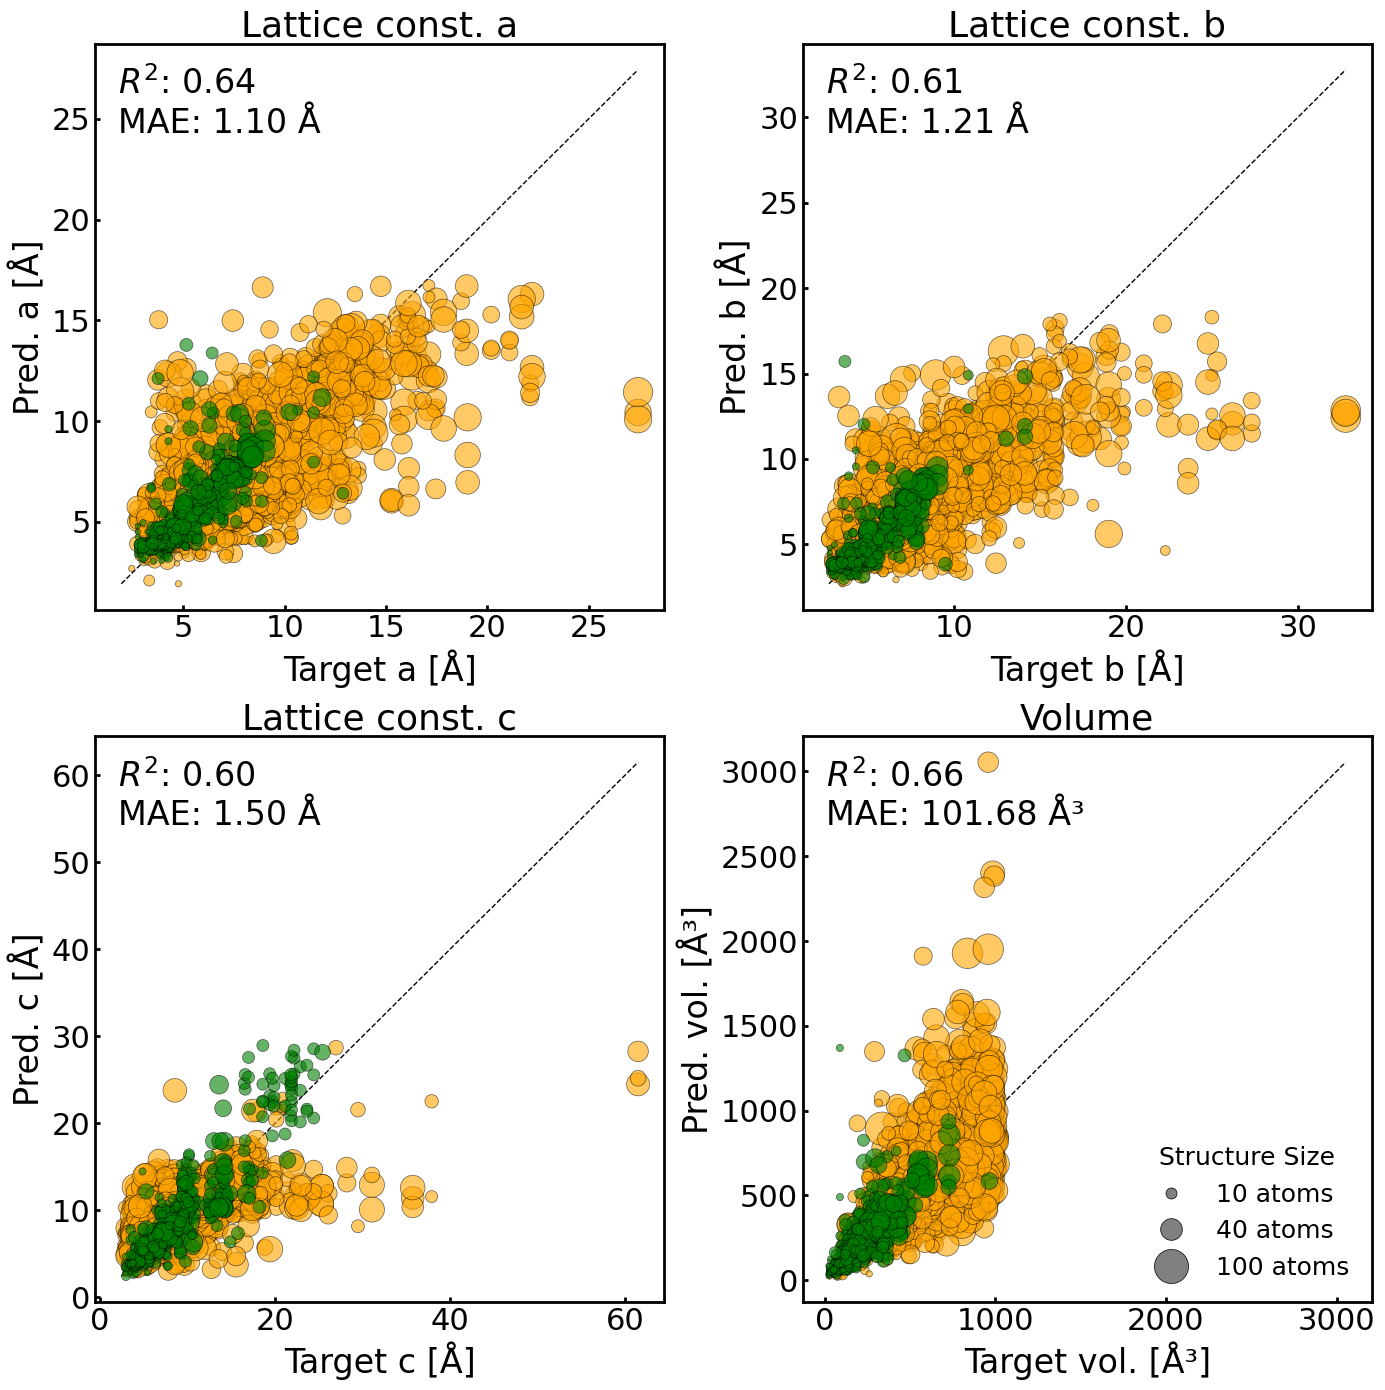

In [2]:
uncond_files = [
    '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics1.parquet',
    '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics2.parquet',
    '_artifacts/chili-xrd/chili-ft-uncond-20perp-test_metrics3.parquet'
]

df_metrics_uncond = load_and_process_xrd_metrics(uncond_files)

plot_true_vs_gen(
    df_metrics_uncond,
    figsize=(14, 14),
    title_fontsize=26,
    label_fontsize=24,
    ticks_fontsize=22,
    legend_fontsize=18,
    annot_fontsize=22,
    scatter_edge_width=0.5,
    alpha_matched=0.6,
    alpha_unmatched=0.6,
    min_marker_size=3,
    size_multiplier=6.0,
    diag_line_width=1.0,
    axes_linewidth=2.0,
    show_match_legend=False,
    show_size_legend=True,
    savepath="plots/chili/chili_xrd_uncond.png"
)

In [3]:
df_metrics

,True Struct,Gen Struct,RMS-d,True a,True b,True c,True volume,Gen a,Gen b,Gen c,Gen volume,Sensible Num,Score,n_matched_struct,atom_counts,is_novel,is_comp_novel,System,conv_count
0,# generated using pymatgen\ndata_Li2TbF6\n_sym...,# generated using pymatgen\ndata_LiTbF6\n_symm...,NaN,7.560000,4.934000,11.066000,394.694928,9.5690,4.9980,10.2930,472.145875,20,1.169627,0,36,False,False,3,32
1,# generated using pymatgen\ndata_Cs2NaAl3F12\n...,# generated using pymatgen\ndata_Cs2NaAl3F12\n...,NaN,7.024225,7.024225,18.245704,779.629079,7.0780,7.0780,20.3910,884.688278,7,1.139967,0,54,True,True,4,54
2,# generated using pymatgen\ndata_Cs2LiAl3F12\n...,# generated using pymatgen\ndata_Cs6Li3Al9F32\...,NaN,6.976724,6.976724,17.562263,740.311020,7.2970,7.2970,17.6180,812.411252,15,1.105532,0,54,True,True,4,50
3,# generated using pymatgen\ndata_Fe2NF6\n_symm...,# generated using pymatgen\ndata_Fe2NF6\n_symm...,0.482004,7.045000,7.454000,10.116000,531.225858,7.2000,7.0300,11.2100,567.405360,20,1.288121,1,36,False,False,3,36
4,# generated using pymatgen\ndata_BaNaCr2F9\n_s...,# generated using pymatgen\ndata_BaNaCr2F9\n_s...,NaN,5.398000,17.311000,9.006647,683.693533,5.2590,17.6950,8.0860,744.104485,20,1.907189,0,52,False,False,4,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4462,# generated using pymatgen\ndata_KFeBr3\n_symm...,# generated using pymatgen\ndata_KFeBr3\n_symm...,0.452972,8.712000,3.845000,14.150000,473.991606,8.9740,3.9260,15.6530,551.485306,20,1.421846,1,20,False,False,3,20
4463,# generated using pymatgen\ndata_CuAsPtS2\n_sy...,# generated using pymatgen\ndata_CuAsPtS2\n_sy...,NaN,3.756000,15.876000,5.852000,348.956258,6.4560,6.4560,6.4560,269.085667,20,1.089854,0,20,True,False,4,20
4464,# generated using pymatgen\ndata_Cu6SO19\n_sym...,# generated using pymatgen\ndata_Cu6SO19\n_sym...,NaN,6.807000,5.897000,20.653000,829.029574,8.7900,4.9700,23.8100,999.876350,20,1.288281,0,52,True,True,3,52
4465,# generated using pymatgen\ndata_Ag2Pd9(PbS2)2...,# generated using pymatgen\ndata_Ag2Pd9(PbS2)2...,NaN,7.973000,7.973000,9.139000,580.954614,7.8392,7.8392,11.2411,690.799955,20,1.062564,0,34,True,True,4,34
